# Hospitality Analysis

In [887]:
import pandas as pd

In [895]:
df_bookings = pd.read_csv("S:/Re start Learn/Python/Hospitality Analysis/fact_bookings.csv")
df_bookings.head(4)


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640


In [896]:
df_bookings.shape

(134590, 12)

In [897]:
df_bookings.room_category.unique()

array(['RT1', 'RT2', 'RT3', 'RT4'], dtype=object)

In [898]:
df_bookings.booking_platform.unique()


array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

In [899]:
df_bookings.booking_platform.value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

<Axes: ylabel='booking_platform'>

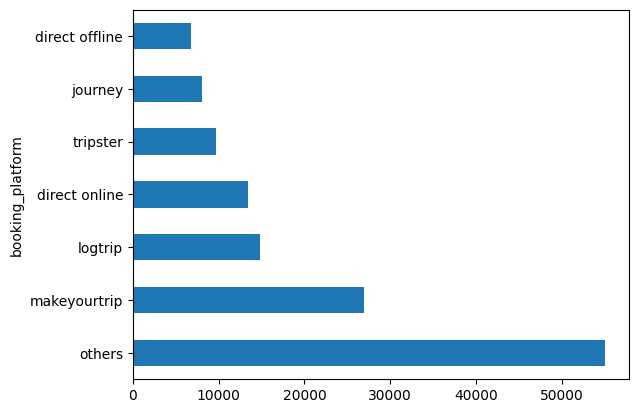

In [900]:
df_bookings.booking_platform.value_counts().plot(kind="barh")

In [894]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [798]:
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(np.int64(6500), np.int64(28560000))

In [799]:
df_date = pd.read_csv("S:/Re start Learn/Python/Hospitality Analysis/dim_date.csv")
df_hotels = pd.read_csv("S:/Re start Learn/Python/Hospitality Analysis/dim_hotels.csv")
df_rooms = pd.read_csv("S:/Re start Learn/Python/Hospitality Analysis/dim_rooms.csv")
df_agg_bookings  = pd.read_csv("S:/Re start Learn/Python/Hospitality Analysis/fact_aggregated_bookings.csv")

In [800]:
df_hotels.shape

(25, 4)

In [801]:
df_hotels.head(4)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi


In [802]:
df_hotels.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

<Axes: xlabel='city'>

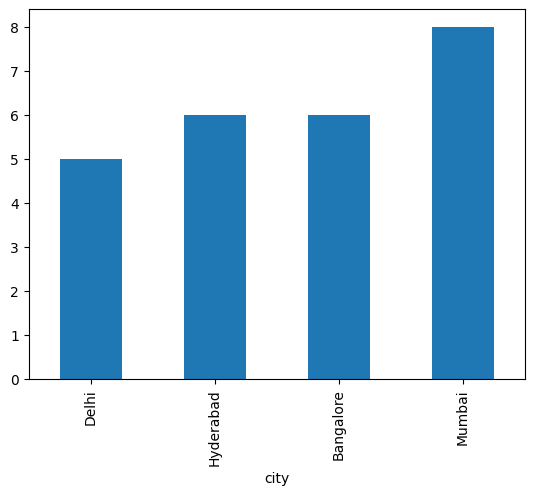

In [803]:
df_hotels.city.value_counts().sort_values().plot(kind="bar")


#  Out Unique property id in booking Hotels

In [804]:
df_bookings.property_id	.unique()

array([16558, 16559, 16560, 16561, 16562, 16563, 17558, 17559, 17560,
       17561, 17562, 17563, 18558, 18559, 18560, 18561, 18562, 18563,
       19558, 19559, 19560, 19561, 19562, 19563, 17564])

In [805]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0


# Total booking per property_id

In [806]:
df_agg_bookings.groupby('property_id')['successful_bookings'].sum()

property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7211
17558    5053
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4737
19558    4400
19559    4729
19560    6079
19561    5736
19562    5812
19563    5413
Name: successful_bookings, dtype: int64

# Out days on which Booking are greater than capacity

In [807]:
df_agg_bookings[df_agg_bookings.successful_bookings>df_agg_bookings.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


#  Out properties that have Highest property capacity

In [808]:
df_agg_bookings.groupby('property_id')['capacity'].max()

property_id
16558    22.0
16559    41.0
16560    34.0
16561    24.0
16562    43.0
16563    41.0
17558    50.0
17559    39.0
17560    45.0
17561    36.0
17562    30.0
17563    44.0
17564    40.0
18558    30.0
18559    44.0
18560    40.0
18561    40.0
18562    38.0
18563    29.0
19558    40.0
19559    41.0
19560    38.0
19561    45.0
19562    30.0
19563    45.0
Name: capacity, dtype: float64

# Data Cleaning

In [809]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


# clean invalid guest

In [810]:
df_bookings[df_bookings.no_guests<=0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


# As you can see above ,numer of guest having less than zero value represent data error we can ignore these records

In [811]:
df_bookings =df_bookings[df_bookings.no_guests>0]
df_bookings.shape

(134578, 12)

# Outlier Removal in reveneue generated

In [812]:
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(np.int64(6500), np.int64(28560000))

In [813]:
avg,std=df_bookings.revenue_generated.mean(),df_bookings.revenue_generated.std()

In [814]:
avg,std

(np.float64(15378.036937686695), np.float64(93040.1549314641))

In [815]:
higher_limit=avg + 3* std
higher_limit

np.float64(294498.50173207896)

In [816]:
lower_limit=avg - 3* std
lower_limit

np.float64(-263742.4278567056)

In [817]:
df_bookings[df_bookings.revenue_generated> higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [818]:
df_bookings=df_bookings[df_bookings.revenue_generated<higher_limit]
df_bookings.shape

(134573, 12)

In [819]:
df_bookings.revenue_realized.describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [820]:
 higher_limit =df_bookings.revenue_realized.mean() + 3*df_bookings.revenue_realized.std()
higher_limit

np.float64(33479.358661845814)

In [821]:
df_bookings[df_bookings.revenue_realized>higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


# One observation we can have in above data frame is that all rooms are Rt4 which mean presidential suit Now since Rt4 is a luxurious room it is likely this rent will be higher to make a fair analysis we need to do data analysis only on rt4 room types.

In [822]:
df_bookings[df_bookings.room_category=="RT4"].revenue_realized.describe()

count    16071.000000
mean     23439.308444
std       9048.599076
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

# mean + 3*standard deviation
23439+3*9048

# Here higher limit comes to be 505583 and in our dataframe above we can see that max value for revenue realized is 45220 hence we can concluide that there is no outlier and we dont need to do any data cleaning on this particular coloumn

In [823]:
df_bookings[df_bookings.booking_id=="May012216558RT213"]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [824]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

# Total values  in our dataframe is 134576. out of that 77899 rows has null rating Since there are many rows with null rating we should not filter these values also we should not replace this rating with median or mean rating etc

# In aggreagate bookings find columns that have null values fill these null values with whatever you thinl is the appropriate subtitute 

In [825]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [826]:
df_agg_bookings[df_agg_bookings.capacity.isna()]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,NaN
14,17562,1-May-22,RT1,12,NaN


In [827]:
df_agg_bookings.capacity.median()

np.float64(25.0)

In [828]:
df_agg_bookings['capacity'] = df_agg_bookings['capacity'].fillna(
    df_agg_bookings['capacity'].median()
)

In [829]:
df_agg_bookings['capacity'].isnull().sum()

np.int64(0)

In [830]:
df_agg_bookings.loc[[8,15]]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,25.0
15,17563,1-May-22,RT1,21,25.0


# In aggregate booking records that have successful_booking value greter than capacity .filter those records

In [831]:
df_agg_bookings[df_agg_bookings.successful_bookings>df_agg_bookings.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


In [832]:
df_agg_bookings.shape

(9200, 5)

In [833]:
df_agg_bookings = df_agg_bookings[df_agg_bookings.successful_bookings<=df_agg_bookings.capacity]
df_agg_bookings.shape

(9194, 5)

# Data Transformation

# Occupancy Percentage column

In [834]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0


In [835]:
df_agg_bookings['occ_pct'] = df_agg_bookings.apply(lambda row:
row['successful_bookings']/row['capacity'], axis=1)

In [836]:
new_col = df_agg_bookings.apply(lambda row: row['successful_bookings']/row['capacity'], axis=1)
df_agg_bookings = df_agg_bookings.assign(occ_pct=new_col.values)
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667


# Convert it to a percentage value

In [837]:
df_agg_bookings['occ_pct'] = pd.to_numeric(df_agg_bookings['occ_pct'], errors='coerce')

In [838]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667


In [839]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100


In [840]:
df_agg_bookings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9194 entries, 0 to 9199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          9194 non-null   int64  
 1   check_in_date        9194 non-null   object 
 2   room_category        9194 non-null   object 
 3   successful_bookings  9194 non-null   int64  
 4   capacity             9194 non-null   float64
 5   occ_pct              9194 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 502.8+ KB


# Insights Generation

# Average is an occupancy rate in each of the room categories

In [841]:
df_agg_bookings.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
4,16558,1-May-22,RT1,18,19.0,0.947368


In [842]:
df_agg_bookings.groupby('room_category')['occ_pct'].mean().round(2)

room_category
RT1    0.58
RT2    0.58
RT3    0.58
RT4    0.59
Name: occ_pct, dtype: float64

In [843]:
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [844]:
df_agg_bookings.groupby("room_category")["occ_pct"].mean().round(2)

room_category
RT1    0.58
RT2    0.58
RT3    0.58
RT4    0.59
Name: occ_pct, dtype: float64

# I dont Understand rt1 ,rt2 etc. print room categories such as standard premium elite etc alomng with average occpancy percentage

In [845]:
df = pd.merge(df_agg_bookings, df_rooms, left_on="room_category", right_on="room_id")
df.tail(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential
9193,17561,31-Jul-22,RT4,3,4.0,0.750000,RT4,Presidential


In [846]:
df.groupby("room_class")["occ_pct"].mean().round(2)

room_class
Elite           0.58
Premium         0.58
Presidential    0.59
Standard        0.58
Name: occ_pct, dtype: float64

In [847]:
df.drop("room_id",axis=1, inplace=True)
df.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,Standard
3,16558,1-May-22,RT1,18,19.0,0.947368,Standard


df[df.room_class=="Standard"].occ_pct.mean()

# Average occupancy rate per city

In [848]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667


In [849]:
df_agg_bookings.groupby("room_category")["occ_pct"].mean()

room_category
RT1    0.578896
RT2    0.580097
RT3    0.580283
RT4    0.592776
Name: occ_pct, dtype: float64

In [850]:
df = pd.merge(df_agg_bookings, df_rooms, left_on="room_category", right_on="room_id")
df.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,RT1,Standard
3,16558,1-May-22,RT1,18,19.0,0.947368,RT1,Standard


# The occupancy better weekday or weekend??

In [851]:
df_date.head(3)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday


In [852]:
df = pd.merge(df, df_date, left_on="check_in_date", 
right_on="date")
df.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class,date,mmm yy,week no,day_type
0,19563,10-May-22,RT3,15,29.0,0.517241,RT3,Premium,10-May-22,May 22,W 20,weekeday
1,18560,10-May-22,RT1,19,30.0,0.633333,RT1,Standard,10-May-22,May 22,W 20,weekeday
2,19562,10-May-22,RT1,18,30.0,0.600000,RT1,Standard,10-May-22,May 22,W 20,weekeday


In [853]:
df.groupby("day_type")["occ_pct"].mean().round(2)

day_type
weekeday    0.51
weekend     0.72
Name: occ_pct, dtype: float64

# Data for the month of august append that to exisying data

In [856]:
df_august = pd.read_csv("S:/Re start Learn/Python/Hospitality Analysis/new_data_august.csv")
df_august.head(5)

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Atliq City,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92


In [857]:
df_august.columns

Index(['property_id', 'property_name', 'category', 'city', 'room_category',
       'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type',
       'successful_bookings', 'capacity', 'occ%'],
      dtype='object')

In [858]:
df.columns

Index(['property_id', 'check_in_date', 'room_category', 'successful_bookings',
       'capacity', 'occ_pct', 'room_id', 'room_class', 'date', 'mmm yy',
       'week no', 'day_type'],
      dtype='object')

In [859]:
df_august.shape

(7, 13)

In [860]:
df.shape

(6497, 12)

In [861]:
latest_df = pd.concat([df, df_august], ignore_index = True, axis = 0)
latest_df.tail(10)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class,date,mmm yy,week no,day_type,property_name,category,city,occ%
6494,17558,31-Jul-22,RT4,3,6.0,0.50,RT4,Presidential,31-Jul-22,Jul 22,W 32,weekend,NaN,NaN,NaN,NaN
6495,19563,31-Jul-22,RT4,3,6.0,0.50,RT4,Presidential,31-Jul-22,Jul 22,W 32,weekend,NaN,NaN,NaN,NaN
6496,17561,31-Jul-22,RT4,3,4.0,0.75,RT4,Presidential,31-Jul-22,Jul 22,W 32,weekend,NaN,NaN,NaN,NaN
6497,16559,01-Aug-22,RT1,30,30.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq Exotica,Luxury,Mumbai,100.00
6498,19562,01-Aug-22,RT1,21,30.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq Bay,Luxury,Bangalore,70.00
6499,19563,01-Aug-22,RT1,23,30.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq Palace,Business,Bangalore,76.67
6500,19558,01-Aug-22,RT1,30,40.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq Grands,Luxury,Bangalore,75.00
6501,19560,01-Aug-22,RT1,20,26.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq City,Business,Bangalore,76.92
6502,17561,01-Aug-22,RT1,18,26.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq Blu,Luxury,Mumbai,69.23
6503,17564,01-Aug-22,RT1,10,16.0,NaN,NaN,Standard,NaN,Aug-22,W 32,weekeday,Atliq Seasons,Business,Mumbai,62.50


In [862]:
latest_df.shape

(6504, 16)

# Revenue realized per City

In [863]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100


In [864]:
df_hotels.head(3)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi


In [865]:
df_bookings_all = pd.merge(df_bookings, df_hotels, on="property_id")
df_bookings_all.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi


In [866]:
df_bookings_all.groupby("city")["revenue_realized"].sum()

city
Bangalore    420383550
Delhi        294404488
Hyderabad    325179310
Mumbai       668569251
Name: revenue_realized, dtype: int64

#  Print Month by month revenue

In [867]:
df_bookings_all.head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi


In [868]:
df_bookings_all['check_in_date'] = df_bookings_all['booking_date']

In [869]:
df_bookings_all[['booking_date', 'check_in_date']].head(10)

,booking_date,check_in_date
0,30-04-22,30-04-22
1,27-04-22,27-04-22
2,1/5/2022,1/5/2022
3,28-04-22,28-04-22
4,26-04-22,26-04-22
5,30-04-22,30-04-22
6,28-04-22,28-04-22
7,29-04-22,29-04-22
8,26-04-22,26-04-22
9,26-04-22,26-04-22


In [870]:
df_date.head(3)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday


In [871]:
pd.merge(df_bookings_all, df_date, left_on="check_in_date",right_on="date").head(10)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type


In [872]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB


In [873]:
pd.to_datetime

<function pandas.core.tools.datetimes.to_datetime(arg: 'DatetimeScalarOrArrayConvertible | DictConvertible', errors: 'DateTimeErrorChoices' = 'raise', dayfirst: 'bool' = False, yearfirst: 'bool' = False, utc: 'bool' = False, format: 'str | None' = None, exact: 'bool | lib.NoDefault' = <no_default>, unit: 'str | None' = None, infer_datetime_format: 'lib.NoDefault | bool' = <no_default>, origin: 'str' = 'unix', cache: 'bool' = True) -> 'DatetimeIndex | Series | DatetimeScalar | NaTType | None'>

In [875]:
df_date["date"]=pd.to_datetime(df_date["date"])
df_date.head(3)

,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday


# revenue realized per hotel type

In [883]:
df_bookings_all.property_name.unique()

array(['Atliq Grands', 'Atliq Exotica', 'Atliq City', 'Atliq Blu',
       'Atliq Bay', 'Atliq Palace', 'Atliq Seasons'], dtype=object)

In [884]:
df_bookings_all.groupby("property_name")["revenue_realized"].sum().round(2).sort_values()

property_name
Atliq Seasons     66086735
Atliq Grands     211462134
Atliq Bay        259996918
Atliq Blu        260851922
Atliq City       285798439
Atliq Palace     304081863
Atliq Exotica    320258588
Name: revenue_realized, dtype: int64

# Average Rating per city

In [885]:
df_bookings_all.groupby("city")["ratings_given"].mean().round(2)

city
Bangalore    3.41
Delhi        3.78
Hyderabad    3.66
Mumbai       3.65
Name: ratings_given, dtype: float64

# Pie chart of revenue relized per booking platform

<Axes: ylabel='revenue_realized'>

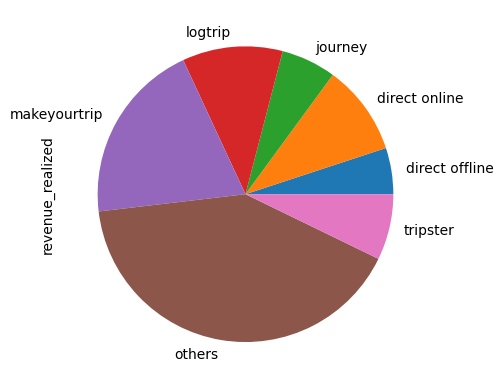

In [886]:
df_bookings_all.groupby("booking_platform")["revenue_realized"].sum().plot(kind="pie")